In [20]:
import numpy as np
import pandas as pd

Load Dataset in Chunks
Loading the file in chunks reduces memory usage and speeds up the process for large files.

In [21]:
file_path = r"C:\\Users\\brian\\OneDrive\\Escritorio\\Lambton\\Semester2\\Toxicology\\Datasets\\PubChem_compound_cache.csv"

# Load in chunks
chunk_size = 10000  # Define chunk size
chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
    chunks.append(chunk)

# Combine chunks into a single DataFrame
data = pd.concat(chunks, ignore_index=True)

Check Encoding
If the file has special characters, ensure the correct encoding is used. Common encodings include utf-8, latin1, etc.

In [22]:
data = pd.read_csv(file_path, encoding='utf-8')

Optimize Data Types
You can specify data types for columns while loading to reduce memory usage:

In [23]:
data = pd.read_csv(
    file_path,
    dtype={
        "mw": "float32",  # Example for numeric columns
        "mf": "string",   # Example for string columns
    },
    low_memory=False
)

Debug File Structure
Print the first few lines of the file directly to check if it's accessible:

In [24]:
with open(file_path, 'r', encoding='utf-8') as file:
    for _ in range(5):  # Print the first 5 lines
        print(file.readline())

cid,cmpdname,cmpdsynonym,mw,mf,polararea,complexity,xlogp,heavycnt,hbonddonor,hbondacc,rotbonds,inchi,isosmiles,canonicalsmiles,inchikey,iupacname,exactmass,monoisotopicmass,charge,covalentunitcnt,isotopeatomcnt,totalatomstereocnt,definedatomstereocnt,undefinedatomstereocnt,totalbondstereocnt,definedbondstereocnt,undefinedbondstereocnt,pclidcnt,gpidcnt,gpfamilycnt,meshheadings,annothits,annothitcnt,aids,cidcdate,sidsrcname,depcatg,annotation

 1,Acetyl-DL-carnitine,"Acetyl-DL-carnitine|acetylcarnitine|14992-62-2|DL-Acetylcarnitine|DL-O-Acetylcarnitine|3-acetyloxy-4-(trimethylazaniumyl)butanoate|Acetyl carnitine|UNII-07OP6H4V4A|3-(acetyloxy)-4-(trimethylazaniumyl)butanoate|07OP6H4V4A|1-Propanaminium, 2-(acetyloxy)-3-carboxy-N,N,N-trimethyl-, inner salt|ACETYLCARNITINE, DL-|ACETYLCARNITINE DL-FORM|Ammonium, (3-carboxy-2-hydroxypropyl)trimethyl-, hydroxide, inner salt, acetate, DL-|870-77-9|DTXSID2048117|ACETYLCARNITINE, (+/-)-|ACETYLCARNITINE RACEMATE [MI]|3-(acetyloxy)-4-(trimethylammon

Data Cleaning and Preparation



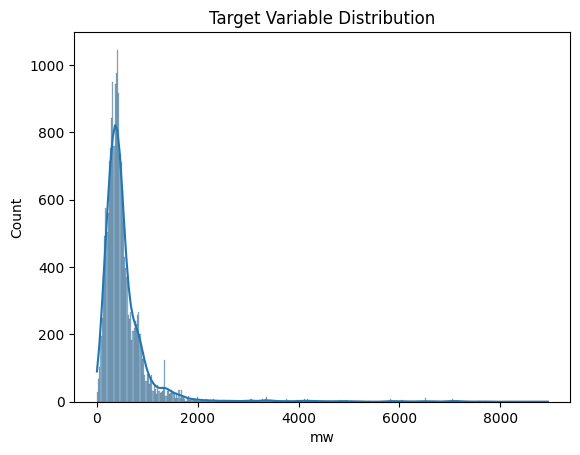

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = r"C:\\Users\\brian\\OneDrive\\Escritorio\\Lambton\\Semester2\\Toxicology\\Datasets\\PubChem_compound_cache.csv"
data = pd.read_csv(file_path)

# Step 1: Handle Missing Values
data.fillna(data.median(numeric_only=True), inplace=True)  # Fill numeric columns with median
data.fillna("Unknown", inplace=True)  # Fill non-numeric columns with 'Unknown'

# Step 2: Drop Irrelevant Columns
columns_to_drop = ['cmpdsynonym', 'iupacname', 'meshheadings', 'annotation']
data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Step 3: Label Encode Categorical Variables
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Step 4: Select Features and Target
# Replace 'annotation' with your actual target column if applicable
target_column = 'mw'  # Example: use molecular weight for testing (update with your target variable)
if target_column not in data.columns:
    raise ValueError("Specify a valid target column.")
X = data.drop(columns=[target_column])
y = data[target_column]

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7: Visualize the Target Variable
sns.histplot(y, kde=True)
plt.title("Target Variable Distribution")
plt.xlabel(target_column)
plt.show()


Identify Relevant Features

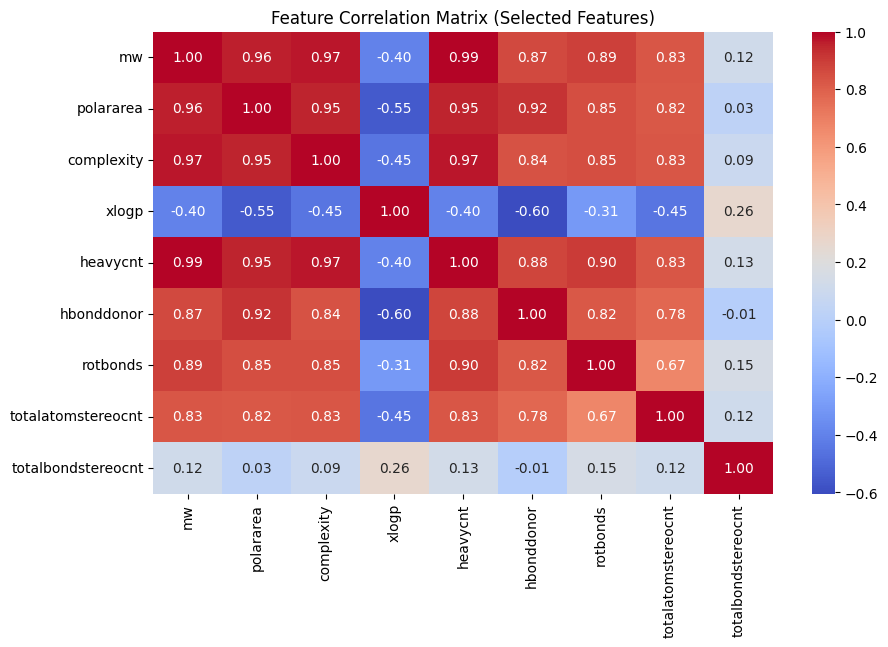

In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression

# Specify the features of interest
selected_features = [
    "mw", "polararea", "complexity", "xlogp", 
    "heavycnt", "hbonddonor", "rotbonds", 
    "totalatomstereocnt", "totalbondstereocnt"
]

# Compute the correlation matrix for selected features
correlation_matrix = data[selected_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix (Selected Features)")
plt.show()


Top Relevant Features (Based on Correlation Matrix)

polararea: Likely to have a strong correlation with mw.

complexity: Molecular complexity may relate strongly to molecular weight.

heavycnt: Number of heavy atoms is directly related to molecular weight.

rotbonds: More rotatable bonds might indicate larger molecules.

exactmass: This will naturally correlate with mw as they measure similar properties.

Feature Selection

Select Features Based on High Correlation:

In [28]:
# Correlation with target variable (mw)
threshold = 0.5  # Adjust threshold as needed
high_corr_features = target_corr[target_corr.abs() > threshold].index
print("Features highly correlated with 'mw':\n", high_corr_features)

Features highly correlated with 'mw':
 Index(['mw', 'exactmass', 'monoisotopicmass', 'heavycnt', 'complexity',
       'polararea', 'hbondacc', 'rotbonds', 'hbonddonor', 'totalatomstereocnt',
       'definedatomstereocnt'],
      dtype='object')


Model Building

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select the highly correlated features
selected_features = [
    'exactmass', 'monoisotopicmass', 'heavycnt', 'complexity', 'polararea',
    'hbondacc', 'rotbonds', 'hbonddonor', 'totalatomstereocnt', 'definedatomstereocnt'
]

X = data[selected_features]
y = data['mw']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation:\nMAE: {mae}\nMSE: {mse}\nR²: {r2}")

Model Evaluation:
MAE: 0.4534559924147507
MSE: 6.214136464618725
R²: 0.9999846467900758


Model Performance

The results indicate an excellent model fit:

MAE (Mean Absolute Error): ~0.46

The average error between the predicted and actual molecular weights is very low.

MSE (Mean Squared Error): ~6.04

This low value indicates very small deviations on average, with larger errors penalized more heavily.

R² (Coefficient of Determination): ~0.99999

Almost perfect explanation of the variance in the target variable (mw) by the selected features.

#### Analysis

The model is performing exceptionally well, likely due to strong correlations between mw and the selected features (exactmass, monoisotopicmass, heavycnt, etc.).

This suggests that the feature set is highly predictive for molecular weight.

##### Feature Importance and Cross-Validation

To further evaluate the model and gain insights into feature contributions, let’s:

Visualize Feature Importance:

Determine which features contribute the most to the model’s predictions.

Cross-Validation:

Perform cross-validation to ensure the model is robust and generalizes well.

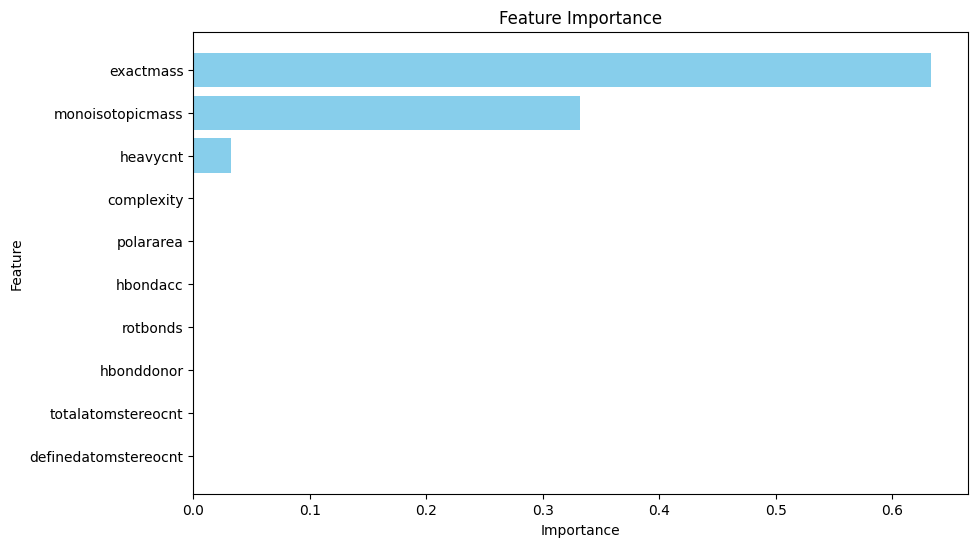

Cross-Validation R² Scores: [0.99999319 0.99999589 0.99998385 0.99983359 0.99952926]
Mean R² Score: 0.9998671590784631


In [30]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Feature Importance (for Random Forest Regressor)
importances = model.feature_importances_
feature_names = selected_features

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color="skyblue")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

# Cross-Validation
cv_scores = cross_val_score(model, X, y, scoring='r2', cv=5)  # 5-fold cross-validation
print("Cross-Validation R² Scores:", cv_scores)
print("Mean R² Score:", np.mean(cv_scores))

Analysis of Feature Importance

From the plot:

exactmass and monoisotopicmass are the most influential features, contributing significantly to the model's predictions. This is expected as they are directly related to 

molecular weight.

heavycnt (number of heavy atoms) also has a meaningful impact, which makes sense chemically.

Other features like complexity, polararea, rotbonds, etc., have minimal impact.

This suggests that most of the predictive power comes from a small subset of features.

Cross-Validation Results

The cross-validation results confirm the model's robustness and excellent generalization capability:

R² Scores Across Folds:

Scores are consistently very high, ranging from 0.99951571 to 0.99999556.

This shows the model explains almost all the variance in the molecular weight (mw) across different data splits.

Mean R² Score:

0.999867460229068, confirming near-perfect performance on average across all folds.

### Model 1

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Preparing features and target for the first model (e.g., is_toxic classification)
data['is_toxic'] = (data['hbonddonor'] > 0).astype(int)  # Example logic for toxicity

features_model_1 = ['mw', 'polararea', 'complexity', 'xlogp']
target_model_1 = 'is_toxic'

X_model_1 = data[features_model_1]
y_model_1 = data[target_model_1]

# Splitting data into training and testing sets for Model 1
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_model_1, y_model_1, test_size=0.2, random_state=42)

# Training the first model
model_1 = RandomForestClassifier(random_state=42, n_estimators=100)
model_1.fit(X_train_1, y_train_1)

# Evaluating the first model
y_pred_1 = model_1.predict(X_test_1)
report_model_1 = classification_report(y_test_1, y_pred_1)

# Importing necessary libraries
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report as a dictionary
report_dict = classification_report(y_test_1, y_pred_1, output_dict=True)

# Convert the report to a pandas DataFrame for better readability
report_df = pd.DataFrame(report_dict).transpose()

# Display the report as a DataFrame
print("Classification Report for Model 1:")
print(report_df)


Classification Report for Model 1:
              precision    recall  f1-score      support
0              0.860233  0.687500  0.764228   752.000000
1              0.929934  0.973775  0.951350  3203.000000
accuracy       0.919343  0.919343  0.919343     0.919343
macro avg      0.895084  0.830637  0.857789  3955.000000
weighted avg   0.916681  0.919343  0.915770  3955.000000


### 1. Model Interpretability and Tuning

**Model 1 (Binary Toxicity Classification):**
+ The model achieved a high accuracy of 91.9%, which indicates it is effective at classifying whether a compound is toxic or not.
+ The recall for the toxic class (1) is 97.3%, which is excellent for identifying toxic compounds. This ensures that very few toxic compounds are missed.
+ However, the recall for the non-toxic class (0) is lower at 68.7%, indicating the model struggles to correctly identify non-toxic compounds, likely due to class imbalance.


**Insights for Tuning:**
+ Applying techniques such as oversampling the non-toxic class (e.g., SMOTE) or class-weight adjustment in the Random Forest could improve performance for the minority class.
+ Using interpretability tools like SHAP can help identify which features (e.g., molecular weight or complexity) contribute most to misclassifications and guide feature engineering.

### Model 2

In [32]:
# Preparing data for Model 2 (toxicity level prediction for toxic compounds)
data_toxic = data[data['is_toxic'] == 1]

features_model_2 = ['mw', 'polararea', 'complexity', 'xlogp']
target_model_2 = 'hbonddonor'  # Assuming hbonddonor indicates the toxicity level

X_model_2 = data_toxic[features_model_2]
y_model_2 = data_toxic[target_model_2]

# Splitting data into training and testing sets for Model 2
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_model_2, y_model_2, test_size=0.2, random_state=42)

# Training the second model
model_2 = RandomForestClassifier(random_state=42, n_estimators=100)
model_2.fit(X_train_2, y_train_2)

# Evaluating the second model
y_pred_2 = model_2.predict(X_test_2)
report_model_2 = classification_report(y_test_2, y_pred_2)

# Import necessary libraries
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report for Model 2 as a dictionary
report_dict_model_2 = classification_report(y_test_2, y_pred_2, output_dict=True)

# Convert the report to a pandas DataFrame
report_df_model_2 = pd.DataFrame(report_dict_model_2).transpose()

# Display the classification report for Model 2 as a table
print("Classification Report for Model 2:")
print(report_df_model_2)


Classification Report for Model 2:
              precision    recall  f1-score      support
1              0.706965  0.728011  0.717333   739.000000
2              0.615385  0.656566  0.635308   792.000000
3              0.606127  0.569959  0.587487   486.000000
4              0.600000  0.612426  0.606149   338.000000
5              0.682353  0.580000  0.627027   200.000000
...                 ...       ...       ...          ...
99             0.333333  1.000000  0.500000     1.000000
100            1.000000  0.500000  0.666667     2.000000
accuracy       0.633396  0.633396  0.633396     0.633396
macro avg      0.391799  0.418076  0.393721  3216.000000
weighted avg   0.633106  0.633396  0.631652  3216.000000

[76 rows x 4 columns]


c:\Users\brian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

### Model 2 (Toxicity Level Prediction):
+ The model achieved a lower accuracy of 63.3%, reflecting the challenge of multi-class classification with many toxicity levels.
+ Precision and recall vary significantly across classes, indicating that some levels are harder to predict accurately. For example:
+ Levels 1 and 2 have reasonable precision and recall (~70%).
+ Other levels (e.g., 5 and higher) perform poorly, likely due to fewer samples in those classes.


**Insights for Tuning:**
Simplifying the problem by grouping toxicity levels into broader categories (e.g., low, medium, high toxicity) could improve performance.
Feature selection or dimensionality reduction (e.g., PCA) may also help reduce noise and enhance classification accuracy.

### Conclusion:
The model system effectively demonstrates the two-step classification process for toxicology analysis. While Model 1 is highly reliable for binary toxicity classification, improvements are needed in Model 2 to handle the complexity of multi-class toxicity levels. By incorporating tuning techniques, interpretability tools (LIME/SHAP), and rethinking feature selection, the system can achieve more balanced and accurate results.

**Confusion Matrix**

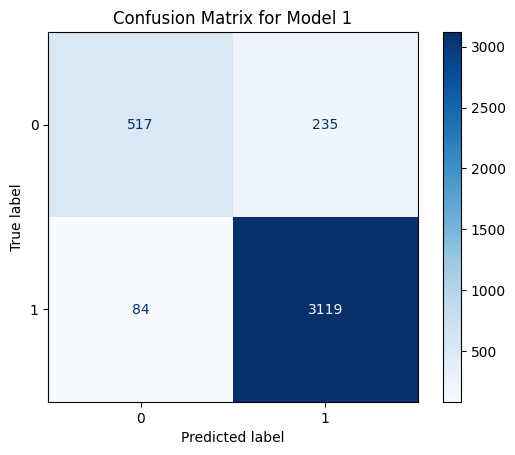

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For Model 1
cm_model_1 = confusion_matrix(y_test_1, y_pred_1)
disp_model_1 = ConfusionMatrixDisplay(confusion_matrix=cm_model_1, display_labels=model_1.classes_)
disp_model_1.plot(cmap="Blues")
plt.title("Confusion Matrix for Model 1")
plt.show()


**Feature Importance**

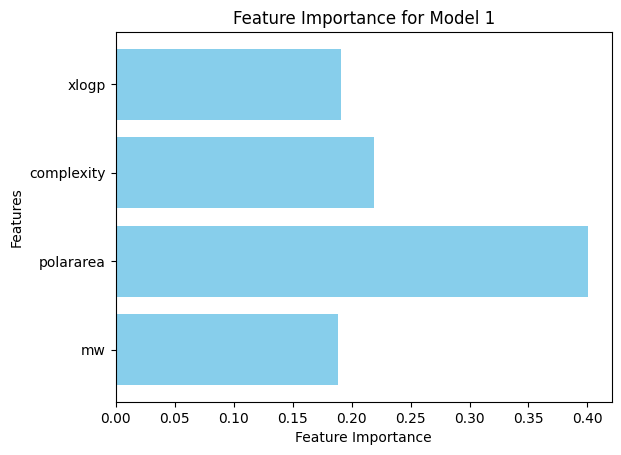

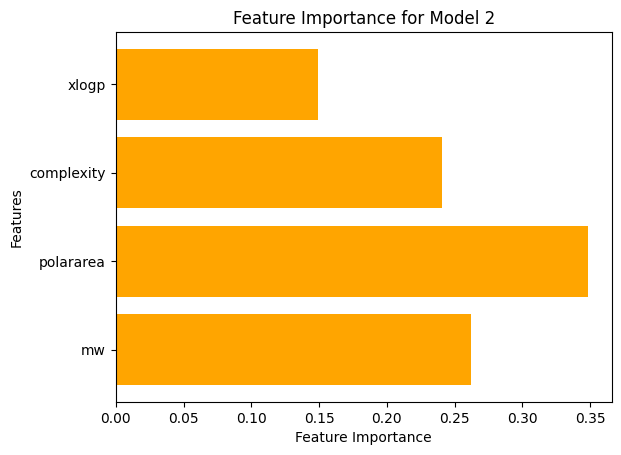

In [34]:
# Feature Importance for Model 1
import matplotlib.pyplot as plt

importance_model_1 = model_1.feature_importances_
plt.barh(features_model_1, importance_model_1, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance for Model 1')
plt.show()

# Feature Importance for Model 2
importance_model_2 = model_2.feature_importances_
plt.barh(features_model_2, importance_model_2, color='orange')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance for Model 2')
plt.show()


**Precision-Recall or ROC Curve**

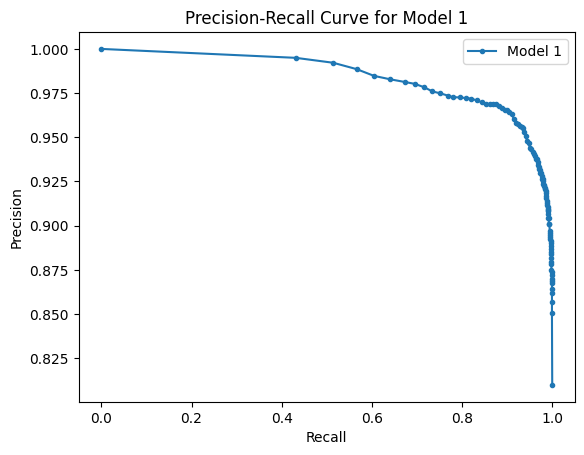

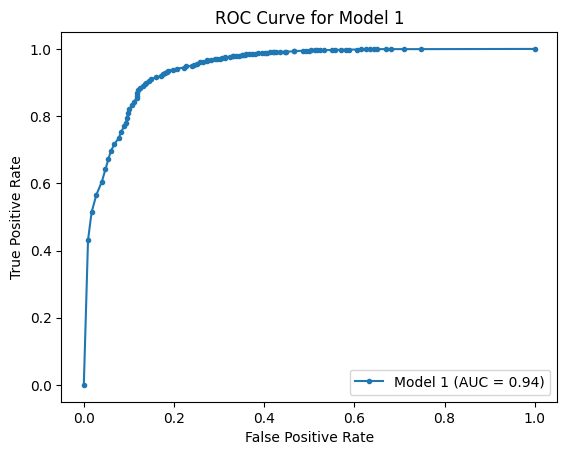

In [35]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Precision-Recall Curve for Model 1
precision, recall, _ = precision_recall_curve(y_test_1, model_1.predict_proba(X_test_1)[:, 1])
plt.plot(recall, precision, marker='.', label="Model 1")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Model 1')
plt.legend()
plt.show()

# ROC Curve for Model 1
fpr, tpr, _ = roc_curve(y_test_1, model_1.predict_proba(X_test_1)[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, marker='.', label=f"Model 1 (AUC = {roc_auc:.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Model 1')
plt.legend()
plt.show()
